# Character-Level Text Generation with a Transformer: Tiny Shakespeare

**Generative task:** unconditional and prompted text generation. The system learns the statistics of Shakespeare's plays one character at a time and then writes new text in the same style.

**Model:** a small decoder-only **Transformer** (Vaswani et al., 2017) implemented from scratch in PyTorch, trained to predict the next character.

**Content produced:** English-like dramatic dialogue, formatted as speaker labels followed by lines of verse or prose.

**Dataset:** the *Tiny Shakespeare* corpus, a 1,115,394-character concatenation of Shakespeare's plays, distributed in the public GitHub repository `karpathy/char-rnn`. The underlying texts are in the public domain. The corpus has not been used in any earlier project in this programme.

The notebook is organised as: setup, data loading and inspection, preprocessing, model definition, training, generation, evaluation of outputs, error and failure analysis, and a closing summary.

## 1. Setup

In [1]:
import math, os, re, time, hashlib, urllib.request, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
DATA_DIR = "data"
FIG_DIR = "figures"
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Model and training configuration
BLOCK_SIZE = 64      # context length in characters
BATCH_SIZE = 32
N_LAYER, N_HEAD, N_EMBD = 4, 4, 128
DROPOUT = 0.1
MAX_STEPS = 2000
WARMUP = 100
LR_MAX, LR_MIN = 3e-3, 3e-4
WEIGHT_DECAY = 0.01
EVAL_EVERY, EVAL_BATCHES = 100, 20

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(2)
sns.set_theme(style="whitegrid", context="notebook")

def set_seed(seed):
    """Make Python, NumPy and PyTorch random number generators repeatable."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(SEED)
print("PyTorch version:", torch.__version__, "| device:", device)

PyTorch version: 2.14.1+cu130 | device: cpu


## 2. Load and Inspect the Data

The corpus is a single plain-text file. If it is not already in the `data` folder, the cell below downloads it from the public repository and checks its SHA-256 checksum against the value recorded when the file was first retrieved, so that a rerun uses identical text.

In [2]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
PATH = os.path.join(DATA_DIR, "input.txt")
SHA256 = "86c4e6aa9db7c042ec79f339dcb96d42b0075e16b8fc2e86bf0ca57e2dc565ed"

def sha256sum(path):
    """Return the SHA-256 checksum of a file."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

if not os.path.exists(PATH):
    urllib.request.urlretrieve(URL, PATH)
assert sha256sum(PATH) == SHA256, "Checksum mismatch: the text differs from the one used in this project"
print("Corpus present and checksum verified.")

with open(PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Characters: {len(text):,}   Lines: {text.count(chr(10)):,}   Words (approx.): {len(text.split()):,}")
print("\n--- First 500 characters ---\n")
print(text[:500])

Corpus present and checksum verified.
Characters: 1,115,394   Lines: 40,000   Words (approx.): 202,651

--- First 500 characters ---

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


Vocabulary size: 65 distinct characters
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

Speaker label lines (for example 'First Citizen:'): 7,960; distinct speakers: 1047
Most common speakers: {'GLOUCESTER:': 229, 'DUKE VINCENTIO:': 193, 'ROMEO:': 163, 'MENENIUS:': 162, 'PETRUCHIO:': 158}


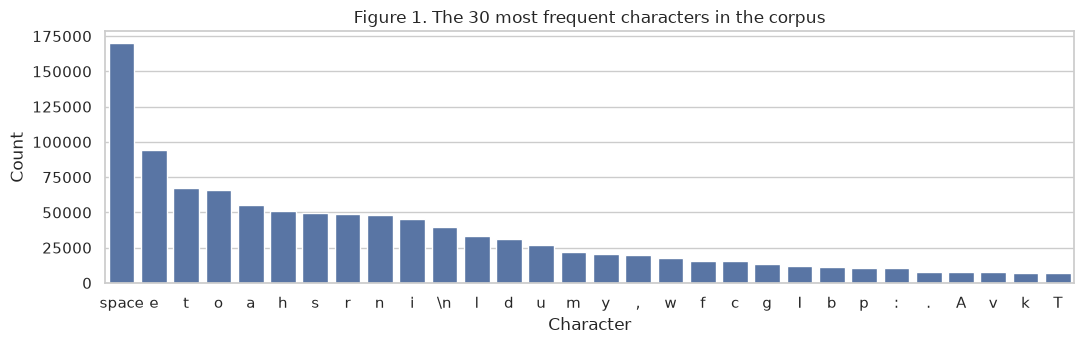

In [3]:
chars = sorted(set(text))
print(f"Vocabulary size: {len(chars)} distinct characters")
print(repr("".join(chars)))

freq = pd.Series(list(text)).value_counts()
speaker_lines = re.findall(r"^[A-Za-z' ]+:$", text, flags=re.M)
print(f"\nSpeaker label lines (for example 'First Citizen:'): {len(speaker_lines):,}; distinct speakers: {len(set(speaker_lines))}")
print("Most common speakers:", pd.Series(speaker_lines).value_counts().head(5).to_dict())

fig, ax = plt.subplots(figsize=(11, 3.6))
top = freq.head(30)
sns.barplot(x=[repr(c)[1:-1] if c != " " else "space" for c in top.index], y=top.values, color="#4C72B0", ax=ax)
ax.set_title("Figure 1. The 30 most frequent characters in the corpus")
ax.set_xlabel("Character"); ax.set_ylabel("Count")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/figure_1_character_frequency.png", dpi=150); plt.show()

**Interpretation.** The corpus holds 1,115,394 characters drawn from 65 distinct symbols, with the space the most frequent character, followed by e, t, o and a, as in ordinary English prose. Its structure is regular: about 7,960 speaker labels (a name in capitals followed by a colon and a newline) separate short speeches of verse or prose. That layout is a pattern the model can learn, and it also makes format errors easy to detect. The spelling and vocabulary are Early Modern English, so a model trained on this text will write in that register and not in modern English. The next cell looks at who speaks and who is spoken about, because that shapes what the model can learn to produce.

In [4]:
import re, collections
words = re.findall(r"[a-z']+", text.lower())
wc = collections.Counter(words)
male = sum(wc[w] for w in ["he", "him", "his", "himself"])
female = sum(wc[w] for w in ["she", "her", "hers", "herself"])
print(f"Male pronoun tokens: {male:,}   Female pronoun tokens: {female:,}   ratio {male/female:.2f} to 1")
speakers = collections.Counter(re.findall(r"^([A-Za-z' ]+):$", text, flags=re.M))
total = sum(speakers.values())
top10 = speakers.most_common(10)
print(f"\nSpeaker lines: {total:,} across {len(speakers):,} distinct labels")
print("Ten most frequent speakers:", [(n, c) for n, c in top10])
print(f"Share of all speaker lines held by these ten: {sum(c for _, c in top10)/total:.1%}")
print("Is 'DENNIS' a speaker in the corpus?", "DENNIS" in speakers)

Male pronoun tokens: 4,370   Female pronoun tokens: 1,350   ratio 3.24 to 1

Speaker lines: 7,960 across 1,047 distinct labels
Ten most frequent speakers: [('GLOUCESTER', 229), ('DUKE VINCENTIO', 193), ('ROMEO', 163), ('MENENIUS', 162), ('PETRUCHIO', 158), ('CORIOLANUS', 149), ('KING RICHARD III', 138), ('ISABELLA', 129), ('JULIET', 125), ('LEONTES', 125)]
Share of all speaker lines held by these ten: 19.7%
Is 'DENNIS' a speaker in the corpus? False


**Interpretation.** The corpus is strongly male-weighted. Male pronouns outnumber female pronouns by 3.24 to 1, and the ten most frequent speakers are mostly men, with only Isabella and Juliet appearing among them. No single speaker dominates (the top ten hold 19.7 per cent of speaker lines), but the language the model sees about and from women is a fraction of what it sees about men. The speaker name 'DENNIS' does not occur in the corpus, which makes it a useful probe in Section 6 of how the model behaves with a speaker it has never seen.

## 3. Preprocessing

**Preprocessing steps and reasons.**

- *Character vocabulary.* Every distinct character (letters, punctuation, space and newline) becomes a token. A character vocabulary is tiny, so the model needs no tokeniser and cannot meet an unknown token, which suits a small-scale project.
- *Encoding.* Each character is mapped to an integer. Case is kept, because capital letters mark speaker names and the start of lines, which the model should learn.
- *Split.* The first 90 per cent of the text is used for training and the last 10 per cent for validation. The split is contiguous and not random, so validation text is a block the model has never seen, and no training window overlaps it.
- *Batches.* Training examples are random windows of 64 characters. The target for each position is simply the next character, so the model learns from all 64 positions in each window at once.

In [5]:
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
VOCAB = len(chars)

def encode(s):
    """Convert a string to a list of integer token ids."""
    return [stoi[c] for c in s]

def decode(ids):
    """Convert a sequence of token ids back to a string."""
    return "".join(itos[int(i)] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
train_text = text[:n_train]
print(f"Training characters: {len(train_data):,}   Validation characters: {len(val_data):,}")

def get_batch(split, generator=None):
    """Draw a random batch of (input, target) windows; the target is the input shifted by one."""
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - BLOCK_SIZE - 1, (BATCH_SIZE,), generator=generator)
    x = torch.stack([d[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([d[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("Batch shapes:", tuple(xb.shape), tuple(yb.shape))
print("Input :", repr(decode(xb[0][:40])))
print("Target:", repr(decode(yb[0][:40])))

Training characters: 1,003,854   Validation characters: 111,540
Batch shapes: (32, 64) (32, 64)
Input : 'd, lips, O you\nThe doors of breath, seal'
Target: ', lips, O you\nThe doors of breath, seal '


## 4. Model Definition

**Architecture.** The model is a decoder-only Transformer, the design used for modern text generators (Vaswani et al., 2017; Radford et al., 2019):

1. A token embedding and a learned position embedding are added, so the model knows both which character it sees and where it is in the window.
2. Four identical blocks follow. Each block applies *causal multi-head self-attention* (four heads) and then a two-layer feed-forward network. Layer normalisation comes before each sub-layer and residual connections wrap each one, which keeps training of a deep stack stable (Ba et al., 2016).
3. A final layer normalisation and a linear layer map each position to 65 scores, one for every character.

**Key design choices.**

- *Causal mask.* A position may attend only to itself and earlier positions. Without the mask, the model could copy the answer from the future character and learn nothing useful about generation.
- *Self-attention, not a recurrent network.* Attention lets every character look directly at any earlier character in the window, for example the speaker label several lines above, without passing information through a long chain of steps.
- *Small size.* About 0.82 million parameters and a 64-character window are chosen so that the model trains in minutes on two CPU cores. This limits how coherent the output can be, which is discussed in the evaluation.
- *Dropout of 0.1* on attention and feed-forward outputs reduces over-fitting on a corpus of only about a million characters.
- *Output.* The final layer produces raw scores (logits). The cross-entropy loss turns them into probabilities, and generation samples from the same probabilities.

In [6]:
class CausalSelfAttention(nn.Module):
    """Multi-head self-attention in which each position sees only earlier positions."""
    def __init__(self):
        super().__init__()
        assert N_EMBD % N_HEAD == 0
        self.qkv = nn.Linear(N_EMBD, 3 * N_EMBD)
        self.proj = nn.Linear(N_EMBD, N_EMBD)
        self.attn_drop = nn.Dropout(DROPOUT)
        self.resid_drop = nn.Dropout(DROPOUT)
        mask = torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)).view(1, 1, BLOCK_SIZE, BLOCK_SIZE)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, N_HEAD, C // N_HEAD).transpose(1, 2)
        k = k.view(B, T, N_HEAD, C // N_HEAD).transpose(1, 2)
        v = v.view(B, T, N_HEAD, C // N_HEAD).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(k.size(-1))
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = self.attn_drop(F.softmax(att, dim=-1))
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))


class Block(nn.Module):
    """One Transformer block: attention then feed-forward, each with pre-normalisation and a residual connection."""
    def __init__(self):
        super().__init__()
        self.ln1 = nn.LayerNorm(N_EMBD)
        self.attn = CausalSelfAttention()
        self.ln2 = nn.LayerNorm(N_EMBD)
        self.mlp = nn.Sequential(nn.Linear(N_EMBD, 4 * N_EMBD), nn.GELU(),
                                 nn.Linear(4 * N_EMBD, N_EMBD), nn.Dropout(DROPOUT))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))


class CharTransformer(nn.Module):
    """Decoder-only Transformer that predicts the next character."""
    def __init__(self):
        super().__init__()
        self.tok = nn.Embedding(VOCAB, N_EMBD)
        self.pos = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.drop = nn.Dropout(DROPOUT)
        self.blocks = nn.Sequential(*[Block() for _ in range(N_LAYER)])
        self.ln_f = nn.LayerNorm(N_EMBD)
        self.head = nn.Linear(N_EMBD, VOCAB)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.drop(self.tok(idx) + self.pos(torch.arange(T, device=idx.device)))
        logits = self.head(self.ln_f(self.blocks(x)))
        loss = None if targets is None else F.cross_entropy(logits.view(-1, VOCAB), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """Extend idx one character at a time by sampling from the predicted distribution."""
        self.eval()
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -BLOCK_SIZE:])
            logits = logits[:, -1, :] / max(temperature, 1e-6)
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float("-inf")
            nxt = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)
            idx = torch.cat([idx, nxt], dim=1)
        return idx


set_seed(SEED)
model = CharTransformer().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {n_params:,}")
print(model)

Trainable parameters: 818,241
CharTransformer(
  (tok): Embedding(65, 128)
  (pos): Embedding(64, 128)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (attn_drop): Dropout(p=0.1, inplace=False)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
    (1): Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttentio

## 5. Training

**Training setup.** The loss is cross-entropy between the predicted distribution and the true next character, averaged over all positions. The optimiser is AdamW (Loshchilov & Hutter, 2019), which applies weight decay separately from the gradient update. The learning rate rises linearly during a short warm-up and then follows a cosine decay, and gradients are clipped to a norm of 1.0, all of which guard against the instability that Transformers can show early in training. Every 100 steps the notebook records the loss on training batches and on held-out validation batches, and it saves a short generated sample so that the progress of the model can be read directly from its writing.

In [7]:
def lr_at(step):
    """Linear warm-up followed by cosine decay."""
    if step < WARMUP:
        return LR_MAX * (step + 1) / WARMUP
    progress = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1 + math.cos(math.pi * progress))

@torch.no_grad()
def estimate_loss():
    """Average the loss over several fixed batches from each split."""
    model.eval()
    out = {}
    for split in ["train", "val"]:
        g = torch.Generator().manual_seed(123)
        losses = []
        for _ in range(EVAL_BATCHES):
            xb, yb = get_batch(split, generator=g)
            losses.append(model(xb, yb)[1].item())
        out[split] = float(np.mean(losses))
    model.train()
    return out

def sample_text(n=200, prompt="\n", temperature=0.8, seed=0):
    """Generate n characters after a prompt using a fixed seed."""
    torch.manual_seed(seed)
    start = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    return decode(model.generate(start, n, temperature=temperature)[0])

optimizer = torch.optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=WEIGHT_DECAY)
history, snapshots = [], {}
snapshots[0] = sample_text(200)
set_seed(SEED)
model.train()
t0 = time.time()
for step in range(1, MAX_STEPS + 1):
    for g in optimizer.param_groups:
        g["lr"] = lr_at(step - 1)
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if step % EVAL_EVERY == 0 or step == 1:
        est = estimate_loss()
        history.append({"step": step, "train_loss": est["train"], "val_loss": est["val"], "lr": lr_at(step - 1)})
        if step % (EVAL_EVERY * 4) == 0 or step == MAX_STEPS:
            print(f"step {step:5d}  train loss {est['train']:.4f}  val loss {est['val']:.4f}  lr {lr_at(step-1):.5f}  ({time.time()-t0:.0f}s)")
    if step in (200, 600, MAX_STEPS):
        snapshots[step] = sample_text(200)
hist = pd.DataFrame(history)
print(f"Training finished in {time.time()-t0:.0f} seconds")

step   400  train loss 1.8799  val loss 2.0011  lr 0.00284  (50s)


step   800  train loss 1.6561  val loss 1.8277  lr 0.00219  (97s)


step  1200  train loss 1.5595  val loss 1.7595  lr 0.00132  (148s)


step  1600  train loss 1.4999  val loss 1.6857  lr 0.00059  (199s)


step  2000  train loss 1.4728  val loss 1.6591  lr 0.00030  (251s)


Training finished in 251 seconds


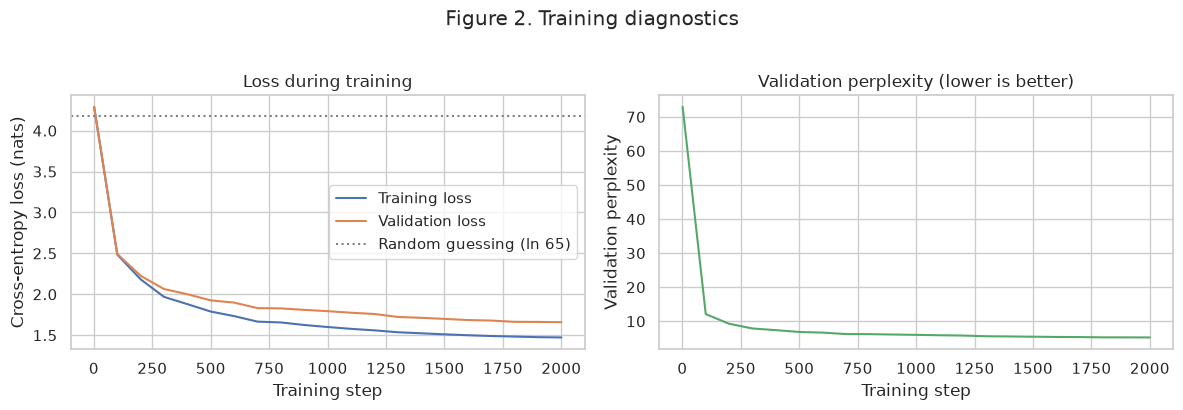

Final training loss 1.4728   validation loss 1.6591
Validation perplexity 5.25   bits per character 2.394
Gap (validation minus training loss): 0.1862


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["step"], hist["train_loss"], label="Training loss", color="#4C72B0")
axes[0].plot(hist["step"], hist["val_loss"], label="Validation loss", color="#DD8452")
axes[0].axhline(math.log(VOCAB), color="grey", ls=":", label=f"Random guessing (ln {VOCAB})")
axes[0].set_xlabel("Training step"); axes[0].set_ylabel("Cross-entropy loss (nats)")
axes[0].set_title("Loss during training"); axes[0].legend()
axes[1].plot(hist["step"], np.exp(hist["val_loss"]), color="#55A868")
axes[1].set_xlabel("Training step"); axes[1].set_ylabel("Validation perplexity")
axes[1].set_title("Validation perplexity (lower is better)")
plt.suptitle("Figure 2. Training diagnostics", y=1.02)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/figure_2_training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

final = hist.iloc[-1]
print(f"Final training loss {final.train_loss:.4f}   validation loss {final.val_loss:.4f}")
print(f"Validation perplexity {math.exp(final.val_loss):.2f}   bits per character {final.val_loss/math.log(2):.3f}")
print(f"Gap (validation minus training loss): {final.val_loss - final.train_loss:.4f}")

**Interpretation.** Training was stable. Both losses start at about 4.3, close to the 4.17 expected from guessing among 65 characters at random, and fall quickly during the first 200 steps and then more slowly, with no spikes or divergence. The final validation loss is 1.659, a perplexity of 5.25 and 2.39 bits per character, so on average the model is about as uncertain as a choice between five equally likely characters. The gap between validation and training loss widened from 0.12 at step 400 to 0.19 at step 2,000, a mild sign of over-fitting that dropout kept small. The validation loss was still falling at the end, so longer training would improve the model further.

The progress samples below show the same story in the writing itself. After step 0 the output is random symbols. After 200 steps it contains word-like fragments ('thor mhis kear sell') with no punctuation structure. After 600 steps capital letters and line breaks appear. After 2,000 steps the model writes complete speaker labels with real character names (ISABELLA, LEONTES) in the correct 'NAME:' layout, although the sentences are still not meaningful.

### How the writing improves during training

In [9]:
for step, s in snapshots.items():
    print(f"===== Sample after {step} training steps (temperature 0.8) =====")
    print(s[:200])
    print()

===== Sample after 0 training steps (temperature 0.8) =====

t3HxjmhPk&kARxTsX?trW?oHDf !egwjnUvzNdkIxAlsvSBUMycoRD$By$XOBnt;zkerM z&?j DJRosOEHelC!BiZ3xhrPB;seMa-B3KyporxiuxMJeJIRc:zZO;fJU,Her?nH-Pmj$!xtsHAHMLpnPjJRnfYHi'fxIiUezEoLH-.c!DSc in
szuzrB3u!rB..SSq

===== Sample after 200 training steps (temperature 0.8) =====

thor mhis kear sell Whou a deamen word I the fand coure you fot beare hath thigh
Anelle sand hist thatho your wake deallos idart, trond; my forsed we woy mar a ma I mervough.
Je con the we mur nou fo

===== Sample after 600 training steps (temperature 0.8) =====

Thy for this wiself made a meathy raid I to the Melcours,
O fram here his done sheir sould fir man wath,
Alordied we and this did trunend have too well your drime him his the hear ands upon
us no. fo

===== Sample after 2000 training steps (temperature 0.8) =====

thou make the prest is of your knews.

ISABELLA:
Now you, he now here hath think of lies.

PRINCE:
Match your wake a man:
What thour need hath too

## 6. Generate Outputs

The model writes one character at a time by sampling from its predicted distribution. Two settings control the result. **Temperature** divides the scores before the softmax: low values make the model pick its favourite characters (safe, repetitive text) and high values flatten the distribution (varied but error-prone text). This trade-off is the usual one for sampling from language models (Holtzman et al., 2020). The cells below show the same prompt at four temperatures, then several different prompts.

In [10]:
@torch.no_grad()
def generate_batch(prompt, n_samples, n_chars, temperature, seed):
    """Generate several samples in parallel from the same prompt."""
    torch.manual_seed(seed)
    start = torch.tensor([encode(prompt)] * n_samples, dtype=torch.long, device=device)
    out = model.generate(start, n_chars, temperature=temperature)
    return [decode(row) for row in out]

TEMPS = [0.5, 0.8, 1.0, 1.3]
for T_ in TEMPS:
    s = generate_batch("ROMEO:\n", 1, 350, T_, seed=7)[0]
    print(f"########## Prompt 'ROMEO:'  temperature {T_} ##########")
    print(s)
    print()

########## Prompt 'ROMEO:'  temperature 0.5 ##########
ROMEO:
Ay, many some too, the fase of and the words
That we damness of my father to see the cause of his stands
And the friends of the father's forth and good the time
And son the is sons of my black.

KING RICHARD III:
You shall have to shall be come a friend to some to shall
And the fear more not heart of the was liege of the stand.

MENENIUS:
Come, bes



########## Prompt 'ROMEO:'  temperature 0.8 ##########
ROMEO:
Ay, many scorn lord, letter your eyes
And him be not the truth to of his weep, and is a charping?

LUCIO:
Away, let's the flatter than the need of me sworn the courses?

Secives:
The was blame man.

MENENIUS:
I cannot, sir.

COMINIUS:
'Tis night, for at the good of honour,
Or when with none is lettend,
When hope I shall have deter no more doth sees



########## Prompt 'ROMEO:'  temperature 1.0 ##########
ROMEO:
At 'tis hoch wills, I have all sue,
We we him be not them watchmer and what have shing of 'twick!

ESANE:
Away, Sir, but Molician;
Elant for your voice.

QUEEN:
Augs on that vrivage; was blugge! Lake the judget;
Then one cheek and this arging! then me, no will people none,
Or when with ning it let right our hope,
I kneel'd thee so night him tows of



########## Prompt 'ROMEO:'  temperature 1.3 ##########
ROMEO:
At 'man hoch wills, I hath all sue,
We we him be now thmen stoul royars thee shall us.
My love bebutge you were her:
God, forgity; to 'tis neeg and I cwilt thus
Augsson that vrivked; was blug make ween touch give,
And not Romeo word
To are cle the from nighty gate;
Would Are confectiful Ination?

Frian, Gessel-uchard laight, upon;
Quaze him tows of



In [11]:
for prompt in ["First Citizen:\n", "KING HENRY:\n", "DENNIS:\n", "To be, or not to be"]:
    s = generate_batch(prompt, 1, 300, 0.8, seed=11)[0]
    print(f"########## Prompt {prompt!r}  temperature 0.8 ##########")
    print(s)
    print()

########## Prompt 'First Citizen:\n'  temperature 0.8 ##########
First Citizen:
The god healt to set the many and dead,
And he was wither not this farewell, be stricking them vow
That exhers, the sea than supel of the sound:
How they intent his galling trement
To be a wish the sent blood commanded marrorious Join.

GREY:
'Tis me senself the did stire of they partning to the war



########## Prompt 'KING HENRY:\n'  temperature 0.8 ##########
KING HENRY:
Cate princely to set the many and dead,
And his done, deunt am burnishments, be stricking them vow
That exhers, the sea than supel of the sound:
How they intent his galling trement
To be a wish the sent blood commanded marrorious Join.

GREY:
'Tis me senself the did stire of they partning to the war



########## Prompt 'DENNIS:\n'  temperature 0.8 ##########
DENNIS:
Come princely to set the many and dead.

COMINIUS:
The enneral brother.

GLOUCESTER:
The langer's give tell hath hearts and of this tongue.

PAURINCE:
Ay, and the seezent the king,
Come, and shall been the creasure is were orabour.

POMPEY:
Provost, as see them I most is his not appeant:
O God?

GLO



########## Prompt 'To be, or not to be'  temperature 0.8 ##########
To be, or not to bear put both shall'st their foul man
And fears that wither not the visances of creal this
A starves that extens, the sea than supe, but the many
Of were to the turn anz cution
their uning and shall been the creasure is were
Are I devil and the 'onour patiences.

BENVOLIO:
Are not now this unglight yo



**Interpretation.** At temperature 0.5 the model writes fluent-looking lines made almost entirely of real words, but they are repetitive and ungrammatical ('And son the is sons of my black'). At 0.8 it produces the best balance: believable speaker names (COMINIUS, LUCIO, MENENIUS), period vocabulary ('Tis night', 'doth') and some invented words ('charping', 'lettend'). At 1.0 and 1.3 invention takes over ('Gessel-uchard', 'Quaze him tows of'), and the text becomes harder to read as English.

Two behaviours deserve attention. First, the prompts 'First Citizen:', 'KING HENRY:' and 'DENNIS:' all lead into almost the same continuation ('to set the many and dead ... marrorious Join'). This happens because the same random seed was used for all three samples, so the sampler makes the same random choices once the text states converge. It is an effect of the experimental setup and not a sign that the model ignores the prompt, and it is a reminder that a single fixed-seed sample can be misleading. Second, the unseen speaker 'DENNIS:' was accepted without difficulty and answered with an ordinary Shakespeare-style reply, which shows that the model learned the format as a template, with no knowledge of who the characters are. The prompt 'To be, or not to be' was not continued with the famous line, so no recitation of a well-known passage was observed.

## 7. Evaluate the Generated Outputs

Text quality has no single accepted score, so the evaluation combines a quantitative check of the model with simple measurable properties of the generated text and a qualitative reading.

1. **Validation loss and perplexity** measure how well the model predicts text it has not seen (computed in Section 5).
2. **Valid-word rate:** the share of generated words that also occur in the training text. Because the model writes character by character, it can invent words, so this is a direct measure of spelling and vocabulary.
3. **Distinct-word ratio:** the number of different words divided by the total, a simple check on repetition.
4. **Verbatim copying:** the length of the longest string of characters in a generated sample that appears unchanged in the training text. This matters for memorisation and for creative ownership.

For each temperature, eight samples of 600 characters are generated from the same prompt (`ROMEO:`), and the figures below are averages.

,Valid-word rate,Distinct-word ratio,Mean longest verbatim copy (chars),Max longest verbatim copy (chars)
Temperature,,,,
0.5,0.953,0.554,20.500,29
0.8,0.878,0.716,19.000,27
1.0,0.831,0.775,18.625,29
1.3,0.670,0.872,15.375,21


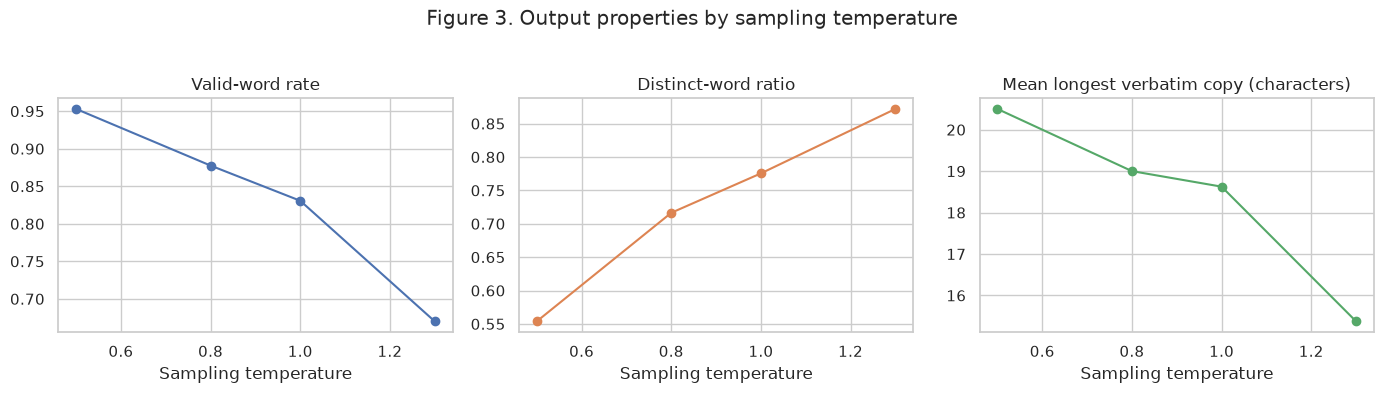

In [12]:
train_words = set(re.findall(r"[a-z']+", train_text.lower()))

def longest_copy(s, corpus):
    """Length of the longest substring of s that occurs verbatim in corpus."""
    best, i = 0, 0
    while i + best < len(s):
        if s[i:i + best + 1] in corpus:
            best += 1
        else:
            i += 1
    return best

def text_metrics(samples):
    """Average valid-word rate, distinct-word ratio and longest verbatim copy over samples."""
    valid, distinct, copies = [], [], []
    for s in samples:
        body = s.split("\n", 1)[1] if "\n" in s else s
        words = re.findall(r"[a-z']+", body.lower())[:-1]  # drop a possibly cut-off last word
        valid.append(np.mean([w in train_words for w in words]))
        distinct.append(len(set(words)) / len(words))
        copies.append(longest_copy(body, train_text))
    return np.mean(valid), np.mean(distinct), np.mean(copies), max(copies)

rows, all_samples = [], {}
for T_ in TEMPS:
    samples = generate_batch("ROMEO:\n", 8, 600, T_, seed=100)
    all_samples[T_] = samples
    v, d, c, cmax = text_metrics(samples)
    rows.append({"Temperature": T_, "Valid-word rate": v, "Distinct-word ratio": d,
                 "Mean longest verbatim copy (chars)": c, "Max longest verbatim copy (chars)": cmax})
metrics = pd.DataFrame(rows).set_index("Temperature")
display(metrics.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(metrics.index, metrics["Valid-word rate"], marker="o", color="#4C72B0"); axes[0].set_title("Valid-word rate")
axes[1].plot(metrics.index, metrics["Distinct-word ratio"], marker="o", color="#DD8452"); axes[1].set_title("Distinct-word ratio")
axes[2].plot(metrics.index, metrics["Mean longest verbatim copy (chars)"], marker="o", color="#55A868"); axes[2].set_title("Mean longest verbatim copy (characters)")
for a in axes:
    a.set_xlabel("Sampling temperature")
plt.suptitle("Figure 3. Output properties by sampling temperature", y=1.03)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/figure_3_temperature_metrics.png", dpi=150, bbox_inches="tight"); plt.show()

**Interpretation.** Temperature moves the three measures in opposite directions, as the sampling literature predicts (Holtzman et al., 2020). The valid-word rate falls from 0.953 at temperature 0.5 to 0.670 at 1.3, so at the highest setting about one word in three is not in the training text. The distinct-word ratio rises from 0.554 to 0.872, showing that low temperature is repetitive (only about half of the words are different) and high temperature is varied but error-prone. Temperature 0.8 gives 0.878 valid words and 0.716 distinct words and is the most useful compromise.

The verbatim-copy measure is low everywhere: the longest string copied unchanged from the training text averages 15 to 21 characters and never exceeds 29. The longest span found (29 characters) was the stock sequence ' my lord.', a blank line and the label 'KING RICHARD III:', which is formatting and not a line of verse. Within this small test, then, the model does not reproduce passages of the plays. The figures come from eight samples of 600 characters per temperature from one prompt and one trained model, so they indicate trends and not precise values.

### Strengths and failure cases

In [13]:
# Words that do not occur in the training text, taken from the temperature 1.0 and 1.3 samples
def invented_words(samples, k=12):
    seen = []
    for s in samples:
        for w in re.findall(r"[a-z']+", s.lower())[:-1]:
            if w not in train_words and w not in seen:
                seen.append(w)
    return seen[:k]

for T_ in [0.8, 1.3]:
    print(f"Temperature {T_}: invented words (not in training text):", invented_words(all_samples[T_]))

# Format check: does each sample open with a speaker label and keep the 'NAME:' layout?
for T_ in TEMPS:
    body = "\n".join(all_samples[T_])
    labels = re.findall(r"^[A-Z][A-Za-z' ]*:$", body, flags=re.M)
    print(f"Temperature {T_}: well-formed speaker label lines across 8 samples = {len(labels)}")

# The longest verbatim copy found at the lowest temperature
low = all_samples[0.5]
best_i = int(np.argmax([longest_copy(s.split("\n", 1)[1], train_text) for s in low]))
body = low[best_i].split("\n", 1)[1]
n = longest_copy(body, train_text)
start = next(i for i in range(len(body) - n + 1) if body[i:i + n] in train_text)
print(f"\nLongest verbatim span at temperature 0.5 ({n} characters):\n{body[start:start + n]!r}")

Temperature 0.8: invented words (not in training text): ['worther', 'gived', 'counself', 'resolves', 'wher', 'hoper', 'dematied', 'helcome', 'sweeth', 'nears', 'worself', 'comforust']
Temperature 1.3: invented words (not in training text): ["franettenm'd", 'ad', 'favist', 'oi', 'haspy', 'thwin', 'chaulticiaus', 'cousint', 'yourgiance', 'clame', 'decapto', "you'arderixle"]
Temperature 0.5: well-formed speaker label lines across 8 samples = 30
Temperature 0.8: well-formed speaker label lines across 8 samples = 33
Temperature 1.0: well-formed speaker label lines across 8 samples = 32
Temperature 1.3: well-formed speaker label lines across 8 samples = 34



Longest verbatim span at temperature 0.5 (29 characters):
' my lord.\n\nKING RICHARD III:\n'


In [14]:
# A closer look at one failure: a long generation drifting at high temperature
s = generate_batch("ROMEO:\n", 1, 400, 1.3, seed=5)[0]
print(s)

ROMEO:
Why, no the coble south frommortaint?

ANGELO:
Cannot may nequitant; in York;
Tesby!

LUCIO:
Where!
'twould cannot. O, Gitlew' out a careat at eince!
I know our great else, to helber I small;?
You. Beven that deech flatured other beane,
The warm, alonderseven minds
Turn respence do feer humand.

SICINIUS:
For yours, by Maplanxor, we now,
On me no serves moves what's complure's lives.

ROMEO:
I no 


**Strengths.** The model learned the layout of a play script almost perfectly: across the eight samples at each temperature, 30 to 34 lines were well-formed speaker labels, and the labels use real names from the corpus (MENENIUS, COMINIUS, GLOUCESTER, LUCIO). It also reproduces period spelling and contractions ('Tis, 'twould, doth, hath) and uses punctuation sensibly, with questions ending in question marks and speeches ending in full stops.

**Failure cases.** (1) *No meaning.* Lines are grammatical in fragments only: 'And son the is sons of my black' and 'The was blame man'. The model sees only 64 characters at a time and was trained for about four passes over the corpus, so it cannot hold a sentence, let alone a plot. (2) *Invented words.* At temperature 0.8 the model produced 'worther', 'gived', 'counself' and 'comforust', and at 1.3 'franettenm'd', 'chaulticiaus' and 'you'arderixle'. (3) *Invented speakers.* Labels such as 'Secives:', 'ESANE:' and 'PAURINCE:' look like names but do not exist. (4) *No consistency.* After the prompt 'ROMEO:' the model quickly moves on to speakers from other plays (KING RICHARD III, MENENIUS), because nothing in its short context ties the scene together. (5) *Drift at high temperature.* The 400-character sample at temperature 1.3 above degrades into strings such as 'Gitlew' out a careat at eince!', where words are no longer recognisable.

## 8. Notebook Summary

**Summary.** I built a small decoder-only Transformer in PyTorch that generates text one character at a time and trained it on the Tiny Shakespeare corpus of about 1.1 million characters. Training was stable and the validation loss fell from 4.3 to 1.66 (perplexity 5.25), while the written samples progressed from random symbols to correctly formatted speaker labels and Early Modern English vocabulary. The generated text imitates the form of a play but has no coherent meaning: at temperature 0.5 it is repetitive, and at 1.3 about a third of the words are invented. The main challenges were the CPU-only budget, which forced a small model and a 64-character context, and the fixed-seed sampling artefact that made different prompts lead to nearly the same continuation. Observed limitations are invented words and speaker names, no long-range consistency, and a male-weighted training corpus (3.24 male pronouns for each female pronoun), although no long verbatim copying of the training text was found.